#**Relatório 1 - Resolução Numérica de Equações Algébricas e Transcendentes**

**Turma:** T2  
**Nome:** Charllynson Carvalho Caxias  
**Matrícula:** 23101741  
**Curso:** Ciência da Computação

##**Importação de bibliotecas**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

##**Implementação dos algoritmos**

### **Algoritmo da Bissecção**

In [ ]:
def bisseccao(f, a, b, e):
    M = f(a)
    k = 1

    if (b - a) < e:
        x = (a + b) / 2
    else:
        while (b - a) >= e:
            x = (a + b) / 2

            if M * f(x) > 0:
                a = x
            else:
                b = x

            if (b - a) < e:
                x = (a + b) / 2
                break

            k = k + 1

    print("Raiz aproximada:", x)
    print("Iterações:", k)
    return x

### **Algoritmo da Falsa Posição**

In [ ]:
def falsa_posicao(f, a, b, e1, e2):
    if (b - a) < e1:
        return (a + b) / 2
    if abs(f(a)) < e2:
        return a
    if abs(f(b)) < e2:
        return b

    k = 1
    M = f(a)

    while True:
        x = (a * f(b) - b * f(a)) / (f(b) - f(a))

        if abs(f(x)) < e2:
            break

        if M * f(x) > 0:
            a = x
        else:
            b = x

        if (b - a) < e1:
            break

        k = k + 1

    print("Raiz aproximada:", x)
    print("Iterações:", k)
    return x

### **Algoritmo de Newton-Raphson**

In [ ]:
def newton_raphson(f, df, x0, e1, e2):
    if abs(f(x0)) < e1:
        print("Raiz aproximada:", x0)
        return x0

    k = 1
    while True:
        x1 = x0 - f(x0) / df(x0)

        if abs(f(x1)) < e1 or abs(x1 - x0) < e2:
            print("Raiz aproximada:", x1)
            print("Iterações:", k)
            return x1

        x0 = x1
        k = k + 1

### **Algoritmo da Secante**

In [ ]:
def secante(f, x0, x1, e1, e2):
    if abs(f(x0)) < e1:
        print("Raiz aproximada:", x0)
        return x0
    if abs(f(x1)) < e1 or abs(x1 - x0) < e2:
        print("Raiz aproximada:", x1)
        return x1

    k = 1
    while True:
        x2 = x1 - (f(x1) * (x1 - x0)) / (f(x1) - f(x0))

        if abs(f(x2)) < e1 or abs(x2 - x1) < e2:
            print("Raiz aproximada:", x2)
            print("Iterações:", k)
            return x2

        x0 = x1
        x1 = x2
        k = k + 1

##**Exercício 1**

In [ ]:
m = 68.1
g = 9.81
t = 10.0
v = 40.0

###**Item a)**

In [ ]:
def f(c):
    return (g * m / c) * (1 - np.exp(-c * t / m)) - v

###**Item b)**

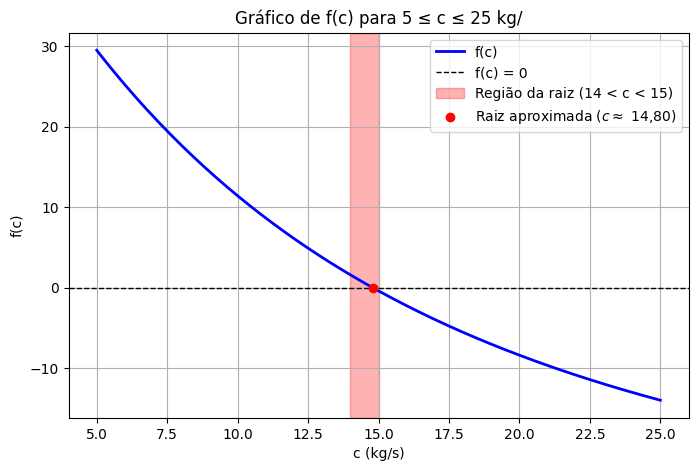

In [ ]:
c = np.linspace(5, 25, 200)
fc = f(c)

plt.figure(figsize=(8, 5))
plt.plot(c, fc, label=r'f(c)', color='blue', linewidth=2)
plt.axhline(0, color='black', linestyle='--', linewidth=1, label=r'f(c) = 0')

plt.axvspan(14, 15, color='red', alpha=0.3, label='Região da raiz (14 < c < 15)')
plt.scatter([14.8011], [0], color='red', zorder=5, label=r'Raiz aproximada ($c \approx$ 14,80)')

plt.title('Gráfico de f(c) para 5 ≤ c ≤ 25 kg/')
plt.xlabel('c (kg/s)')
plt.ylabel('f(c)')
plt.grid(True)
plt.legend()
plt.show()

###**Item c)**

In [ ]:
c1 = 10
c2 = 20
fc1 = f(c1)
fc2 = f(c2)

print("Valor de f(c), com c = 10:", fc1)
print("Valor de f(c), com c = 20:", fc2)

Valor de f(c), com c = 10: 11.42152148536995
Valor de f(c), com c = 20: -8.368384465361824


A troca de sinal no intervalo garante que a raiz está "presa" entre os limites $c_l$ e $c_u$. Em cada iteração, o método calcula o ponto médio $c_r$ e escolhe o subintervalo em que $f(c_l) \cdot f(c_r) < 0$, reduzindo o intervalo de busca pela metade e assegurando a convergência global do algoritmo.

###**Item d)**

In [ ]:
def bisseccao_tabela(f, cl, cu, e=0.0001, max_iter=8):
    cr_old = None
    print(
        f"{'i':>3} | {'cl':>10} | {'cu':>10} | {'cr':>10} | {'f(cr)':>11} | {'ea (%)':>10}"
    )
    print("-" * 65)

    for i in range(1, max_iter + 1):
        cr = (cl + cu) / 2.0
        f_cr = f(cr)

        ea = abs((cr - cr_old) / cr) * 100 if cr_old is not None else None
        ea_str = f"{ea:9.4f}%" if ea is not None else f"{'-':>10}"

        print(
            f"{i:3d} | {cl:10.5f} | {cu:10.5f} | {cr:10.5f} | {f_cr:11.5f} | {ea_str}"
        )

        if f(cl) * f_cr < 0:
            cu = cr
        else:
            cl = cr

        cr_old = cr


bisseccao_tabela(f, cl=10.0, cu=20.0, e=0.0001, max_iter=8)

  i |         cl |         cu |         cr |       f(cr) |     ea (%)
-----------------------------------------------------------------
  1 |   10.00000 |   20.00000 |   15.00000 |    -0.38446 |          -
  2 |   10.00000 |   15.00000 |   12.50000 |     4.91893 |   20.0000%
  3 |   12.50000 |   15.00000 |   13.75000 |     2.13515 |    9.0909%
  4 |   13.75000 |   15.00000 |   14.37500 |     0.84430 |    4.3478%
  5 |   14.37500 |   15.00000 |   14.68750 |     0.22239 |    2.1277%
  6 |   14.68750 |   15.00000 |   14.84375 |    -0.08289 |    1.0526%
  7 |   14.68750 |   14.84375 |   14.76562 |     0.06928 |    0.5291%
  8 |   14.76562 |   14.84375 |   14.80469 |    -0.00692 |    0.2639%


###**Item e)**

O parâmetro $c$ representa o coeficiente de arrasto aerodinâmico do ar, determinando a intensidade da força que se opõe à queda livre. Como a força de resistência é modelada por Fd = c * v, um aumento no valor de c faz com que a resistência do ar exercida sobre o paraquedista seja maior para qualquer velocidade instantânea. Em termos dinâmicos, esse aumento no arrasto força o sistema a atingir mais rápido o equilíbrio com a força peso, resultando em uma velocidade limite menor, expressa por v_limite = mg/c. Portanto, um aumento em $c$ corresponde a uma frenagem aerodinâmica mais intensa, o que reduz a velocidade de queda do paraquedista ao longo do tempo e proporciona uma descida mais lenta e segura.

##**Exercício 2**

In [ ]:
b = 3.0
n = 0.025
S = 0.001
Q = 5.0


###**Item a)**

In [ ]:
def f(y):
    A = b * y
    Rh = (b * y) / (b + 2 * y)

    return (1 / n) * A * (Rh ** (2 / 3)) * (S ** 0.5) - Q

###**Item b)**

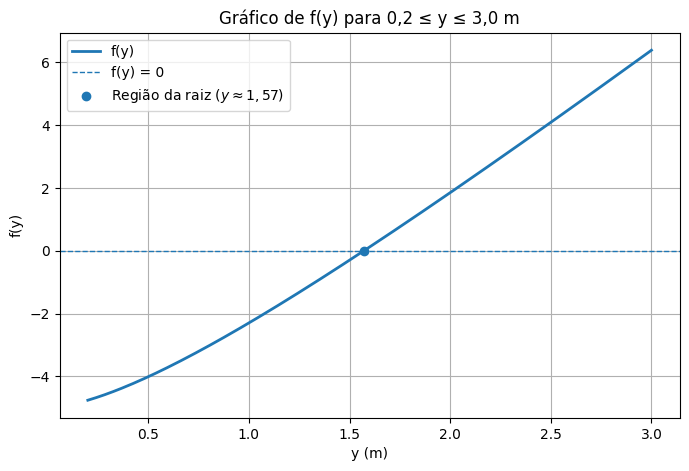

In [ ]:
y = np.linspace(0.2, 3.0, 200)
fy = f(y)

plt.figure(figsize=(8, 5))
plt.plot(y, fy, label=r'f(y)', linewidth=2)
plt.axhline(0, linestyle='--', linewidth=1, label=r'f(y) = 0')

plt.scatter([1.57], [f(1.57)], zorder=5,
            label=r'Região da raiz ($y \approx 1,57$)')

plt.title('Gráfico de f(y) para 0,2 ≤ y ≤ 3,0 m')
plt.xlabel('y (m)')
plt.ylabel('f(y)')
plt.grid(True)
plt.legend()
plt.show()

###**Item c)**

In [ ]:
def falsa_posicao_tabela(f, yl, yu, e1=0.0001, e2=0.0001):
    yr_old = None
    M = f(yl)
    i = 1

    print(
        f"{'i':>3} | {'yl':>10} | {'yu':>10} | "
        f"{'yr':>10} | {'f(yr)':>12} | {'ea (%)':>10}"
    )
    print("-" * 70)

    while True:
        yr = (yl * f(yu) - yu * f(yl)) / (f(yu) - f(yl))
        f_yr = f(yr)

        if yr_old is None:
            ea = None
            ea_str = f"{'-':>10}"
        else:
            ea = abs((yr - yr_old) / yr) * 100
            ea_str = f"{ea:10.6f}"

        print(
            f"{i:3d} | {yl:10.6f} | {yu:10.6f} | "
            f"{yr:10.6f} | {f_yr:12.8f} | {ea_str}"
        )

        if abs(f_yr) < e2:
            break

        if M * f_yr > 0:
            yl = yr
        else:
            yu = yr

        if (yu - yl) < e1:
            break

        yr_old = yr
        i += 1

    print("\nRaiz aproximada:", yr)
    print("Iterações:", i)

    return yr

In [ ]:
y = falsa_posicao_tabela(f, 0.2, 3.0, 0.0001, 0.0001)

  i |         yl |         yu |         yr |        f(yr) |     ea (%)
----------------------------------------------------------------------
  1 |   0.200000 |   3.000000 |   1.396134 |  -0.73183022 |          -
  2 |   1.396134 |   3.000000 |   1.561080 |  -0.04510758 |  10.566116
  3 |   1.561080 |   3.000000 |   1.571175 |  -0.00256937 |   0.642536
  4 |   1.571175 |   3.000000 |   1.571750 |  -0.00014568 |   0.036571
  5 |   1.571750 |   3.000000 |   1.571783 |  -0.00000826 |   0.002073

Raiz aproximada: 1.5717827579028574
Iterações: 5


###**Item d)**

A Falsa Posição e a Bissecção preservam um intervalo contendo a raiz, mas calculam o ponto de aproximação de maneiras diferentes. Na Bissecção: yr = (yl + yu) / 2. Na Falsa Posição: yr = (yl*f(yu) - yu*f(yl)) / (f(yu) - f(yl)). Por isso, na Falsa Posição o ponto yr depende dos valores de f(yl) e f(yu), não sendo necessariamente o ponto médio do intervalo.

###**Item e)**

In [ ]:
print("Profundidade final:", y, "m")
print("Profundidade final:", y * 100, "cm")

Profundidade final: 1.5717827579028574 m
Profundidade final: 157.17827579028574 cm


A profundidade obtida foi $$ y \approx 1,5718\text{ m} \approx 157,18\text{ cm} $$ Isso significa que, para um canal retangular com 3,0 m de largura, rugosidade \(n=0,025\) e declividade \(S=0,001\), é necessária uma lâmina d'água de aproximadamente 1,57 m para transportar a vazão desejada de \(5,0\,m^3/s\). Do ponto de vista do dimensionamento, essa profundidade representa a profundidade hidráulica necessária para atender à vazão especificada. Assim, o canal deverá ter uma profundidade construtiva maior que 1,57 m, caso seja necessário considerar uma margem de segurança ou borda livre para evitar transbordamentos.



---



##**Exercício 3**

In [ ]:
P = 10.0
a = 3.592
b = 0.04267
R = 0.08314
T = 300.0

###**Item a)**

In [ ]:
def f(v):
    return (P + a / v**2) * (v - b) - R * T

###**Item b)**

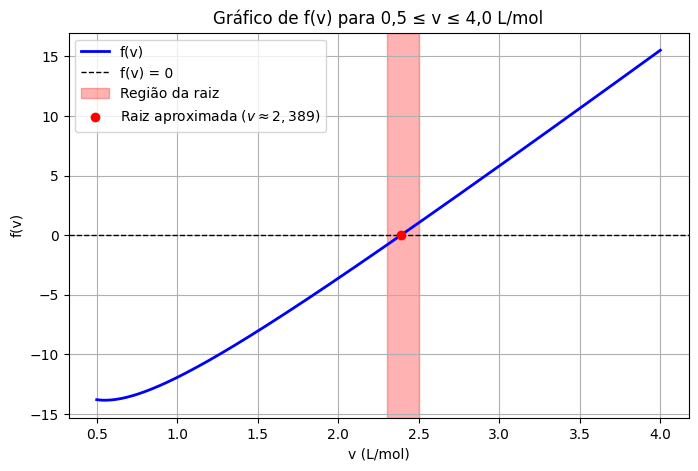

In [ ]:
v = np.linspace(0.5, 4.0, 300)
fv = f(v)

plt.figure(figsize=(8, 5))
plt.plot(v, fv, label=r'f(v)', color='blue', linewidth=2)
plt.axhline(0, color='black', linestyle='--', linewidth=1, label=r'f(v) = 0')

plt.axvspan(2.3, 2.5, color='red', alpha=0.3,
            label='Região da raiz')

plt.scatter([2.3892], [0], color='red', zorder=5,
            label=r'Raiz aproximada ($v \approx 2,389$)')

plt.title('Gráfico de f(v) para 0,5 ≤ v ≤ 4,0 L/mol')
plt.xlabel('v (L/mol)')
plt.ylabel('f(v)')
plt.grid(True)
plt.legend()
plt.show()

###**Item c)**

In [ ]:
v_ideal = R * T / P

print("Volume molar pelo gás ideal:", v_ideal, "L/mol")

Volume molar pelo gás ideal: 2.4942 L/mol


A equação de gás ideal despreza as interações intermoleculares e o volume próprio das moléculas. Porém, ela fornece uma boa estimativa inicial para o volume molar. Além disso, \(v_{ideal}=2,4942\ L/mol\) está muito próximo da raiz da equação de van der Waals, que será aproximadamente \(2,3892\ L/mol\). Isso torna o valor uma escolha adequada para iniciar o método de Newton-Raphson.

###**Item d)**

In [ ]:
def newton_raphson_tabela(f, df, x0, e1=0.0001, e2=0.0001):
    print(
        f"{'i':>3} | {'vi':>10} | {'f(vi)':>12} | "
        f"{f'(vi)':>12} | {'vi+1':>10} | {'ea (%)':>10}"
    )
    print("-" * 75)

    i = 1

    while True:
        f_vi = f(x0)
        df_vi = df(x0)

        x1 = x0 - f_vi / df_vi

        ea = abs((x1 - x0) / x1) * 100

        print(
            f"{i:3d} | {x0:10.6f} | {f_vi:12.8f} | "
            f"{df_vi:12.8f} | {x1:10.6f} | {ea:10.6f}"
        )

        if abs(f(x1)) < e1 or abs(x1 - x0) < e2:
            break

        x0 = x1
        i += 1

    print("\nRaiz aproximada:", x1)
    print("Iterações:", i)

    return x1

In [ ]:
v = newton_raphson_tabela(f, df, v_ideal, 0.0001, 0.0001)

  i |         vi |        f(vi) |         (vi) |       vi+1 |     ea (%)
---------------------------------------------------------------------------
  1 |   2.494200 |   0.98880364 |  17.66310092 |   2.438219 |   2.295992
  2 |   2.438219 |   0.46091167 |  16.83473105 |   2.410840 |   1.135646
  3 |   2.410840 |   0.20326700 |  16.43644947 |   2.398473 |   0.515613
  4 |   2.398473 |   0.08700823 |  16.25802139 |   2.393122 |   0.223629
  5 |   2.393122 |   0.03672093 |  16.18109170 |   2.390852 |   0.094919
  6 |   2.390852 |   0.01540108 |  16.14852183 |   2.389898 |   0.039906
  7 |   2.389898 |   0.00644208 |  16.13484342 |   2.389499 |   0.016709
  8 |   2.389499 |   0.00269160 |  16.12911869 |   2.389332 |   0.006984
  9 |   2.389332 |   0.00112406 |  16.12672624 |   2.389263 |   0.002917

Raiz aproximada: 2.3892625789855058
Iterações: 9


###**Item e)**

In [ ]:
v_ideal = R * T / P

delta_v = abs(v - v_ideal) / v_ideal * 100

print("Volume pela equação de van der Waals:", v, "L/mol")
print("Volume pelo gás ideal:", v_ideal, "L/mol")
print("Diferença percentual:", delta_v, "%")

Volume pela equação de van der Waals: 2.3892625789855058 L/mol
Volume pelo gás ideal: 2.4942 L/mol
Diferença percentual: 4.207257678393651 %


O volume molar calculado pela equação de van der Waals é aproximadamente 4,21% menor que o valor previsto pela lei dos gases ideais. Isso mostra que, nas condições consideradas, principalmente devido à pressão de \(10\) bar, as interações intermoleculares e o volume finito das moléculas já produzem uma diferença perceptível em relação ao comportamento ideal. Portanto, embora a aproximação de gás ideal forneça um valor próximo e tenha sido adequada como estimativa inicial para o Newton-Raphson, a equação de van der Waals fornece uma representação mais realista do comportamento do \(CO_2\) nessas condições.

##**Exercício 4**

In [ ]:
Vs = 5.0
R = 1000.0
Is = 1.0e-12
n = 1.7
VT = 25.85e-3

###**Item a)**

In [ ]:
def f(VD):
    ID = Is * (np.exp(VD / (n * VT)) - 1)
    IR = (Vs - VD) / R

    return ID - IR

###**Item b)**

In [ ]:
def ID(VD):
    return Is * (np.exp(VD / (n * VT)) - 1)

def IR(VD):
    return (Vs - VD) / R

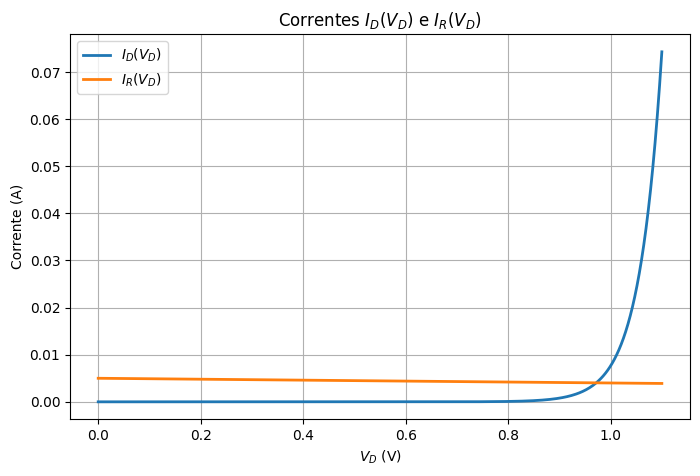

In [ ]:
VD = np.linspace(0, 1.1, 500)

plt.figure(figsize=(8, 5))

plt.plot(VD, ID(VD), label=r'$I_D(V_D)$', linewidth=2)
plt.plot(VD, IR(VD), label=r'$I_R(V_D)$', linewidth=2)

plt.xlabel(r'$V_D$ (V)')
plt.ylabel('Corrente (A)')
plt.title(r'Correntes $I_D(V_D)$ e $I_R(V_D)$')
plt.grid(True)
plt.legend()

plt.show()

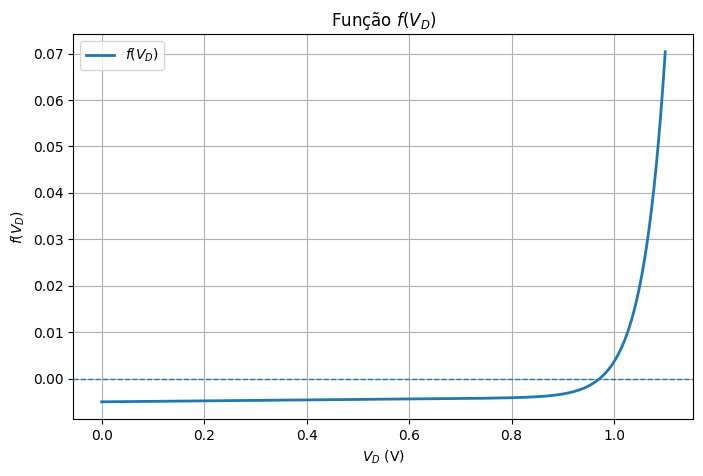

In [ ]:
VD = np.linspace(0, 1.1, 500)

plt.figure(figsize=(8, 5))

plt.plot(VD, f(VD), label=r'$f(V_D)$', linewidth=2)
plt.axhline(0, linestyle='--', linewidth=1)

plt.xlabel(r'$V_D$ (V)')
plt.ylabel(r'$f(V_D)$')
plt.title(r'Função $f(V_D)$')
plt.grid(True)
plt.legend()

plt.show()

###**Item c)**

In [ ]:
x0 = 0.95
x1 = 1.00

print("V0 =", x0, "V")
print("V1 =", x1, "V")

V0 = 0.95 V
V1 = 1.0 V


###**Item d)**

In [ ]:
def secante_tabela(f, x0, x1, e1=0.0001, e2=0.0001):

    print(
        f"{'i':>3} | {'V(i-1)':>10} | {'Vi':>10} | "
        f"{'f(V(i-1))':>14} | {'f(Vi)':>14} | "
        f"{'Vi+1':>10} | {'ea (%)':>10}"
    )

    print("-" * 100)

    i = 1

    while True:

        f0 = f(x0)
        f1 = f(x1)

        x2 = x1 - f1 * (x1 - x0) / (f1 - f0)

        ea = abs((x2 - x1) / x2) * 100

        print(
            f"{i:3d} | {x0:10.6f} | {x1:10.6f} | "
            f"{f0:14.8f} | {f1:14.8f} | "
            f"{x2:10.6f} | {ea:10.6f}"
        )

        if abs(f(x2)) < e1 or abs(x2 - x1) < e2:
            break

        x0 = x1
        x1 = x2
        i += 1

    print("\nRaiz aproximada:", x2)
    print("Iterações:", i)

    return x2

In [ ]:
VD = secante_tabela(f, 0.95, 1.00, 0.0001, 0.0001)

  i |     V(i-1) |         Vi |      f(V(i-1)) |          f(Vi) |       Vi+1 |     ea (%)
----------------------------------------------------------------------------------------------------
  1 |   0.950000 |   1.000000 |    -0.00160348 |     0.00363278 |   0.965311 |   3.593521
  2 |   1.000000 |   0.965311 |     0.00363278 |    -0.00056839 |   0.970005 |   0.483830
  3 |   0.965311 |   0.970005 |    -0.00056839 |    -0.00017302 |   0.972058 |   0.211286

Raiz aproximada: 0.9720583369500198
Iterações: 3


###**Item e)**

Uma vantagem do Método da Secante em relação ao Newton-Raphson é que ele não necessita do cálculo da derivada da função. O Newton-Raphson utiliza $$ x_{i+1}=x_i-\frac{f(x_i)}{f'(x_i)} $$

sendo assim, é necessário conhecer ou calcular f'(x). Já o Método da Secante aproxima a derivada utilizando dois pontos $$ \frac{f(x_i)-f(x_{i-1})}{x_i-x_{i-1}} $$

Assim, ele pode ser mais conveniente quando a derivada da função é difícil de obter ou calcular. Uma desvantagem é que o Método da Secante não garante que os valores permaneçam em um intervalo contendo a raiz. Na Falsa Posição, por exemplo, o intervalo é preservado porque, a cada iteração, verifica-se a mudança de sinal. Na Secante isso não acontece. Consequentemente, dependendo da função e dos valores iniciais, o método pode se afastar da raiz, convergir para outra raiz ou até mesmo divergir. Neste exercício, os valores iniciais \(0,95\) V e \(1,00\) V estão próximos da solução e o método converge para VD = 0,972